In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from MAE.component_model        import ComponentMAE
from MAE.loss_functions          import (
    CrossMaskConsistencyLoss,
    ComponentReconstructionLoss,
    RoutingLoss,
    MaskedReconstructionLoss,
)
from DCGAN.unet                  import UNet
from DCGAN.patch_discriminator   import PatchDiscriminator
from CityScapes.datasets         import CityscapesDataset
from DCGAN.loss_functions        import (
    EntropyLoss,
    TotalVariationLoss,
    WGANGPLoss,
)

device            = "cuda" if torch.cuda.is_available() else "cpu"
scale_for_display = lambda x: x.mul(0.5).add(0.5).clamp(0, 1)
print(f"Device: {device}")

Device: cuda


In [3]:
# ── Data ─────────────────────────────────────────────────────────────────────
IMG_SIZE   = 256
BATCH_SIZE = 8

# ── ComponentMAE ─────────────────────────────────────────────────────────────
PATCH_SIZE         = 16
IN_CHANNELS        = 3
MASK_RATIO         = 0.5
N_COMPONENTS       = 1

ENCODER_EMBED_DIM  = 768
ENCODER_DEPTH      = 12
ENCODER_NUM_HEADS  = 12

DECODER_EMBED_DIM  = 512
DECODER_DEPTH      = 12
DECODER_NUM_HEADS  = 16
MLP_RATIO          = 4.0
DROPOUT            = 0.2

# ── Segmentation UNet ────────────────────────────────────────────────────────
SEG_CHANNELS        = [256, 128, 64, 32, 32, 32, 16]
SEG_CUT_CONNECTIONS = 4

# ── Optimisers ───────────────────────────────────────────────────────────────
REC_MODEL_LR = 1.0e-4
SEG_MODEL_LR = 1.0e-4

# ── Loss weights ─────────────────────────────────────────────────────────────
RECON_WEIGHT          = 10.0   # full-image MSE on blended output
PER_COMP_RECON_WEIGHT = 0.1    # per-component MSE before blending (anti-collapse)
ENTROPY_WEIGHT        = 0.01
TV_WEIGHT             = 0.01
LABEL_SMOOTHING       = 0
ROUTING_LOSS_WEIGHT   = 0.01
CM_WEIGHT             = 0.1    # cross-mask consistency (start small, ramp up)
CM_FM_WEIGHT          = 0.0    # feature-matching weight inside CM loss (set > 0 together with ADV_WEIGHT)

# ── Patch Discriminator ──────────────────────────────────────────────────────
ADV_WEIGHT = 0.01  # set > 0 to enable; complement to MSE on every masked patch
LAMBDA_GP  = 10.0
DRIFT_W    = 0.001
N_CRITIC      = 3
GAN_FM_RATIO  = 0.1   # weight of real/fake term relative to feature matching (keeps FM dominant)
DISC_LR    = 1.0e-4

GRID_SIZE   = IMG_SIZE // PATCH_SIZE
NUM_PATCHES = GRID_SIZE ** 2


In [4]:
msg_dataset  = CityscapesDataset()
train_loader = DataLoader(msg_dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Dataset: {len(msg_dataset)} samples  |  {len(train_loader)} batches/epoch")

Dataset: 19998 samples  |  2500 batches/epoch


In [5]:
# One shared ViT encoder  +  N_COMPONENTS independent shallow decoders.
# Each decoder's mask_token is the per-component prior.
rec_model = ComponentMAE(
    img_size             = IMG_SIZE,
    patch_size           = PATCH_SIZE,
    in_channels          = IN_CHANNELS,
    encoder_embed_dim    = ENCODER_EMBED_DIM,
    encoder_depth        = ENCODER_DEPTH,
    encoder_num_heads    = ENCODER_NUM_HEADS,
    decoder_embed_dim    = DECODER_EMBED_DIM,
    decoder_depth        = DECODER_DEPTH,
    decoder_num_heads    = DECODER_NUM_HEADS,
    mlp_ratio            = MLP_RATIO,
    mask_ratio           = MASK_RATIO,
    dropout              = DROPOUT,
    number_of_components = N_COMPONENTS,
).to(device)

rec_model_optimizer = optim.Adam(rec_model.parameters(), lr=REC_MODEL_LR)
print(f"ComponentMAE parameters: {rec_model.num_parameters:,}")

ComponentMAE parameters: 124,264,448


In [6]:
seg_model = UNet(
    channels        = SEG_CHANNELS,
    out_channels    = N_COMPONENTS,
    cut_connections = SEG_CUT_CONNECTIONS,
).to(device)

seg_model_optimizer = optim.Adam(seg_model.parameters(), lr=SEG_MODEL_LR)
print(f"UNet parameters: {sum(p.numel() for p in seg_model.parameters() if p.requires_grad):,}")

discriminator       = PatchDiscriminator(in_channels=IN_CHANNELS).to(device)
disc_optimizer      = optim.Adam(discriminator.parameters(), lr=DISC_LR, betas=(0.0, 0.9))
wgan_gp_fn          = WGANGPLoss(lambda_gp=LAMBDA_GP, drift_weight=DRIFT_W)
print(f"PatchDiscriminator parameters: {discriminator.num_parameters:,}")

UNet parameters: 4,241,889
PatchDiscriminator parameters: 659,905


In [7]:
reconstruction_loss_fn = MaskedReconstructionLoss(weight=RECON_WEIGHT)
per_comp_recon_loss_fn = ComponentReconstructionLoss(weight=PER_COMP_RECON_WEIGHT)
entropy_loss_fn        = EntropyLoss(weight=ENTROPY_WEIGHT)
tv_loss_fn             = TotalVariationLoss(weight=TV_WEIGHT)
routing_loss_fn        = RoutingLoss(weight=ROUTING_LOSS_WEIGHT)
cm_loss_fn             = CrossMaskConsistencyLoss(weight=CM_WEIGHT, fm_weight=CM_FM_WEIGHT)


/tmp/ipykernel_1114319/4134823866.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


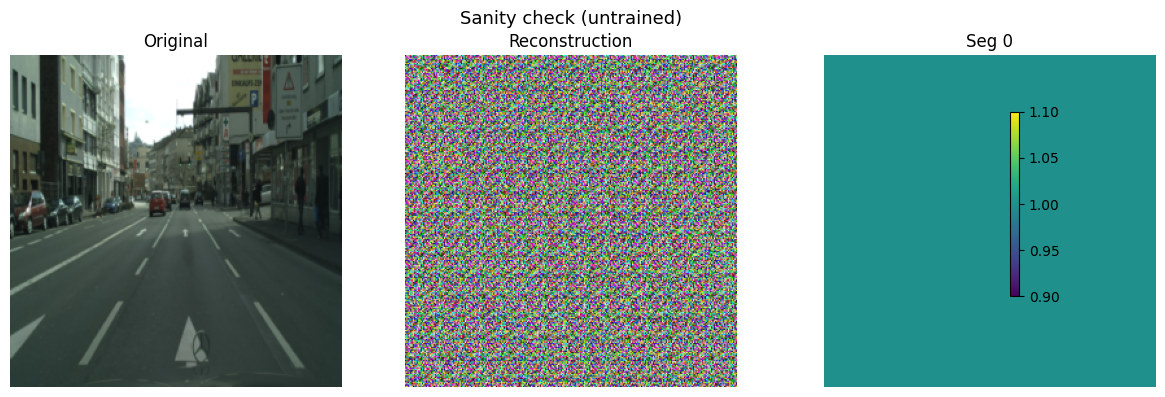

Input mean: -0.3679  |  Rec mean: -0.0078


In [8]:
data, _ = next(iter(train_loader))

with torch.no_grad():
    x          = data.to(device)
    seg_logits = seg_model(x)
    seg_probs  = torch.softmax(seg_logits, dim=1)          # (B, N_comp, H, W)

    component_preds, mask = rec_model(x)                   # (B, N_comp, N, patch_dim)
    comp_preds_list = [component_preds[:, k] for k in range(N_COMPONENTS)]
    independent_recs = torch.stack(
        [torch.tanh(rec_model.unpatchify(p)) for p in comp_preds_list], dim=1
    )                                                      # (B, N_comp, C, H, W)
    reconstructions = (independent_recs * seg_probs.unsqueeze(2)).sum(dim=1)

fig, ax = plt.subplots(1, 2 + N_COMPONENTS, figsize=(4 * (2 + N_COMPONENTS), 4))

ax[0].imshow(scale_for_display(x)[0].cpu().permute(1, 2, 0).numpy())
ax[0].set_title("Original");  ax[0].axis("off")

ax[1].imshow(scale_for_display(reconstructions)[0].cpu().permute(1, 2, 0).numpy())
ax[1].set_title("Reconstruction");  ax[1].axis("off")

vmin, vmax = seg_probs[0].min().item(), seg_probs[0].max().item()
for i in range(N_COMPONENTS):
    im = ax[2 + i].imshow(seg_probs[0, i].cpu().numpy(), vmin=vmin, vmax=vmax, cmap="viridis")
    ax[2 + i].set_title(f"Seg {i}");  ax[2 + i].axis("off")

fig.colorbar(im, ax=ax[2:].tolist(), shrink=0.6)
plt.suptitle("Sanity check (untrained)", fontsize=13)
plt.tight_layout()
plt.show()
print(f"Input mean: {x.mean():.4f}  |  Rec mean: {reconstructions.mean():.4f}")

In [ ]:
epochs                     = 100
entropy_temp               = 0.1
cm_temp                    = 0  # ramp up after recon_loss stabilises
per_comp_recon_loss_weight = 1
ADV_WEIGHT                 = 0.1
# ── patch extraction helpers (used by adversarial loss) ───────────────────────
def _extract_patches(img, mask, P):
    """img (B,C,H,W)  mask (B,N) 1=keep → (K,C,P,P)"""
    B, C, H = img.shape[:3]
    h = H // P
    x = img.reshape(B, C, h, P, h, P).permute(0, 2, 4, 1, 3, 5).reshape(B * h * h, C, P, P)
    return x[mask.reshape(B * h * h).bool()]

def _extract_patchspace(preds, mask, C, P):
    """preds (B,N,C*P*P)  mask (B,N) 1=keep → (K,C,P,P) tanh-activated"""
    B, N, dim = preds.shape
    flat = preds.reshape(B * N, dim)
    sel  = flat[mask.reshape(B * N).bool()]
    return torch.tanh(sel).reshape(-1, C, P, P)

for epoch in range(epochs):
    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs - 1}")
    cm_temp  = min(10.0, cm_temp + 0.2)
    for data, _ in loop:
        full_img = data.to(device)

        # ── 1. Segmentation forward ───────────────────────────────────────
        seg_logits    = seg_model(full_img)
        seg_probs_raw = F.softmax(seg_logits, dim=1)

        entropy_loss = entropy_temp * entropy_loss_fn(seg_logits)
        tv_loss      = entropy_temp * tv_loss_fn(seg_probs_raw)

        if LABEL_SMOOTHING > 0:
            seg_probs_smooth = (seg_probs_raw * (1.0 - LABEL_SMOOTHING)) + (LABEL_SMOOTHING / N_COMPONENTS)
        else:
            seg_probs_smooth = seg_probs_raw

        # ── 2. Pass A: ComponentMAE forward with attention ────────────────
        component_preds_a, mask_a, attn_weights_a = rec_model(full_img, return_attn=True)

        # convert to image space once — all losses consume (B, C, H, W) tensors
        independent_recs_a = torch.stack(
            [torch.tanh(rec_model.unpatchify(component_preds_a[:, k])) for k in range(N_COMPONENTS)],
            dim=1,
        )  # (B, N_comp, C, H, W)
        comp_imgs_list_a = [independent_recs_a[:, k] for k in range(N_COMPONENTS)]

        # ── 3. Pass A losses ──────────────────────────────────────────────
        # Detach independent_recs so recon_loss only trains seg_model through
        # blending weights, not by making one decoder dominate
        blended    = (independent_recs_a * seg_probs_smooth.unsqueeze(2)).sum(dim=1)
        recon_loss = reconstruction_loss_fn(blended, full_img, mask_a)

        # per_comp_recon_loss = per_comp_recon_loss_weight * per_comp_recon_loss_fn(
        #     component_imgs = comp_imgs_list_a,
        #     target_imgs    = full_img,
        #     mask           = mask_a,
        # )

        # routing_loss = routing_loss_fn(
        #     seg_logits     = seg_logits,
        #     component_imgs = comp_imgs_list_a,
        #     full_img       = full_img,
        # )

        # # ── 4. Pass B: inverted mask + cross-mask consistency loss ────────
        component_preds_b, mask_b = rec_model(full_img, mask=1.0 - mask_a)
        comp_preds_list_b = [component_preds_b[:, k] for k in range(N_COMPONENTS)]

        # cm_loss = cm_temp * cm_loss_fn(
        #     seg_probs     = seg_probs_raw,
        #     attn_weights  = attn_weights_a,
        #     mask_a        = mask_a,
        #     pass_b_preds  = comp_preds_list_b,
        #     target_imgs   = full_img,
        #     discriminator = discriminator if ADV_WEIGHT > 0 else None,
        # )

        # ── 5. Adversarial patch losses ───────────────────────────────────────
        if ADV_WEIGHT > 0:
            P     = rec_model.patch_size
            C_img = rec_model.in_channels
            mask_b = (1.0 - mask_a)

            real_a = _extract_patches(full_img, mask_a, P)
            real_b = _extract_patches(full_img, mask_b, P)

            fake_blended = _extract_patches(blended, mask_a, P)
            fake_comps_a = [_extract_patches(img_k, mask_a, P)                          for img_k in comp_imgs_list_a]
            fake_comps_b = [_extract_patchspace(comp_preds_list_b[k], mask_b, C_img, P) for k in range(N_COMPONENTS)]

            all_real = torch.cat([real_a] * (1 + N_COMPONENTS) + [real_b] * N_COMPONENTS)
            all_fake = torch.cat([fake_blended] + fake_comps_a + fake_comps_b)

            for _ in range(N_CRITIC):
                d_loss = wgan_gp_fn.critic_loss(discriminator, all_real, all_fake.detach())
                disc_optimizer.zero_grad()
                d_loss.backward()
                disc_optimizer.step()

            def _adv(real, fake):
                fm  = wgan_gp_fn.feature_matching_loss(discriminator, real, fake)
                gan = wgan_gp_fn.generator_loss(discriminator, fake)
                return fm + GAN_FM_RATIO * gan

            adv_loss = ADV_WEIGHT * (
                _adv(real_a, fake_blended)
                + sum(_adv(real_a, fk) for fk in fake_comps_a)
                + sum(_adv(real_b, fk) for fk in fake_comps_b)
            )
        else:
            adv_loss = torch.tensor(0.0, device=full_img.device)
            d_loss   = torch.tensor(0.0, device=full_img.device)

        loss = (
            recon_loss
            # + per_comp_recon_loss
            # + entropy_loss
            # + tv_loss
            # + routing_loss
            # + cm_loss
            + adv_loss
        )

        # ── 5. Backward ───────────────────────────────────────────────────
        seg_model_optimizer.zero_grad()
        rec_model_optimizer.zero_grad()
        loss.backward()
        seg_model_optimizer.step()
        rec_model_optimizer.step()

        loop.set_postfix(
            loss     = loss.item(),
            recon    = recon_loss.item(),
            # per_comp = per_comp_recon_loss.item(),
            # cm       = cm_loss.item(),
            adv      = adv_loss.item(),
            # entropy  = entropy_loss.item(),
            # tv       = tv_loss.item(),
            # routing  = routing_loss.item(),
            disc_loss = d_loss.item(),
        )

    torch.save(seg_model.state_dict(), "seg_model.pt")
    torch.save(rec_model.state_dict(), "rec_model.pt")
    torch.save(discriminator.state_dict(), "discriminator.pt")


Epoch 0/99:   9%|▉         | 230/2500 [01:11<11:46,  3.21it/s, adv=0.124, disc_loss=-2.98, loss=0.704, recon=0.58]  

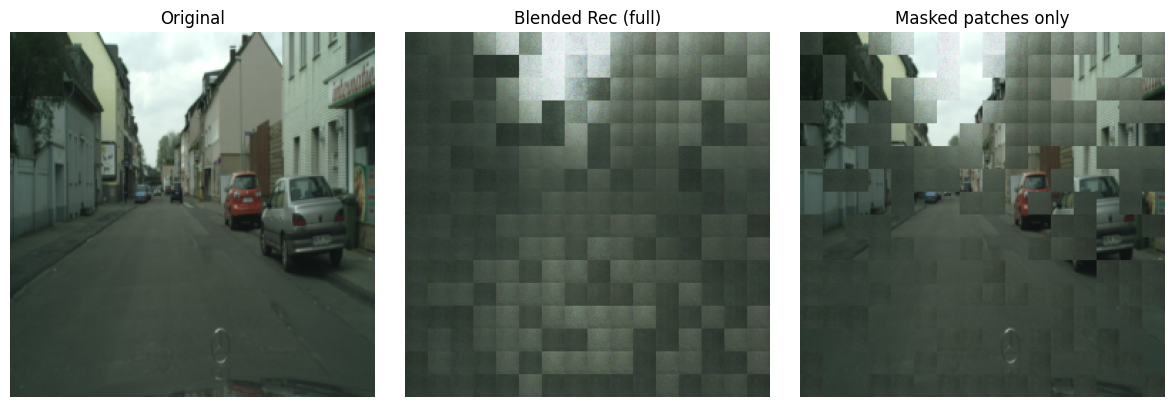

In [19]:
# ── Visualisation 1: original | blended reconstruction | masked-only rec ─────
data, _ = next(iter(train_loader))

with torch.no_grad():
    x          = data.to(device)
    seg_logits = seg_model(x)
    seg_probs  = torch.softmax(seg_logits, dim=1)

    component_preds, mask = rec_model(x)
    comp_preds_list  = [component_preds[:, k] for k in range(N_COMPONENTS)]
    independent_recs = torch.stack(
        [torch.tanh(rec_model.unpatchify(p)) for p in comp_preds_list], dim=1
    )
    blended = (independent_recs * seg_probs.unsqueeze(2)).sum(dim=1)

    # replace visible patches with original image so the plot only shows
    # what the decoder actually reconstructed (masked positions)
    B, _, H, W = x.shape
    h       = int(mask.shape[1] ** 0.5)
    P       = H // h
    mask_px = mask.reshape(B, 1, h, h).float()
    mask_px = F.interpolate(mask_px, scale_factor=float(P), mode="nearest")
    vis_recon = blended * mask_px + x * (1 - mask_px)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(scale_for_display(x)[0].cpu().permute(1, 2, 0).numpy())
axes[0].set_title("Original");  axes[0].axis("off")

axes[1].imshow(scale_for_display(blended)[0].cpu().permute(1, 2, 0).numpy())
axes[1].set_title("Blended Rec (full)");  axes[1].axis("off")

axes[2].imshow(scale_for_display(vis_recon)[0].cpu().permute(1, 2, 0).numpy())
axes[2].set_title("Masked patches only");  axes[2].axis("off")

plt.tight_layout()
plt.savefig("claude.png")
plt.show()

Component 0 mean seg prob: 1.0000


/tmp/ipykernel_1111340/3016929200.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


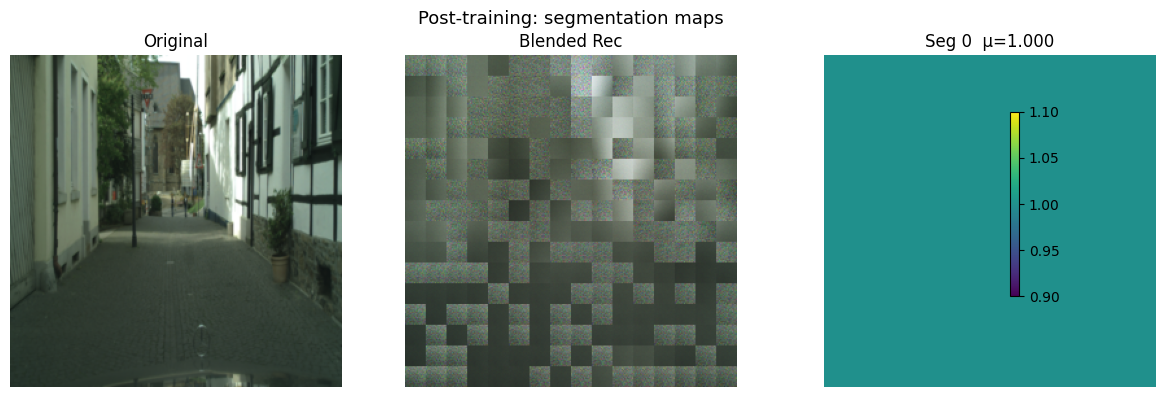

In [ ]:
# ── Visualisation 2: original | blended rec | seg maps ───────────────────────
data, _ = next(iter(train_loader))

with torch.no_grad():
    x          = data.to(device)
    seg_logits = seg_model(x)
    seg_probs  = torch.softmax(seg_logits, dim=1)

    component_preds, mask = rec_model(x)
    comp_preds_list  = [component_preds[:, k] for k in range(N_COMPONENTS)]
    independent_recs = torch.stack(
        [torch.tanh(rec_model.unpatchify(p)) for p in comp_preds_list], dim=1
    )
    reconstructions  = (independent_recs * seg_probs.unsqueeze(2)).sum(dim=1)

fig, ax = plt.subplots(1, 2 + N_COMPONENTS, figsize=(4 * (2 + N_COMPONENTS), 4))

ax[0].imshow(scale_for_display(x)[0].cpu().permute(1, 2, 0).numpy())
ax[0].set_title("Original");  ax[0].axis("off")

ax[1].imshow(scale_for_display(reconstructions)[0].cpu().permute(1, 2, 0).numpy())
ax[1].set_title("Blended Rec");  ax[1].axis("off")

vmin, vmax = seg_probs[0].min().item(), seg_probs[0].max().item()
for i in range(N_COMPONENTS):
    im = ax[2 + i].imshow(seg_probs[0, i].cpu().numpy(), vmin=vmin, vmax=vmax, cmap="viridis")
    mean_val = seg_probs[0, i].mean().item()
    ax[2 + i].set_title(f"Seg {i}  μ={mean_val:.3f}");  ax[2 + i].axis("off")
    print(f"Component {i} mean seg prob: {mean_val:.4f}")

fig.colorbar(im, ax=ax[2:].tolist(), shrink=0.6)
plt.suptitle("Post-training: segmentation maps", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Visualisation 3: per-component reconstructions ───────────────────────────
# Columns: Original | Blended Rec | Comp-0 | ... | Comp-(N-1)
N_SHOW = min(4, BATCH_SIZE)

n_cols = 2 + N_COMPONENTS
fig, axes = plt.subplots(N_SHOW, n_cols, figsize=(3.5 * n_cols, 3.5 * N_SHOW),
                         squeeze=False)

col_titles = (["Original", "Blended Rec"] +
              [f"Component {i}" for i in range(N_COMPONENTS)])
for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, fontsize=10, fontweight="bold")

for row in range(N_SHOW):
    axes[row][0].imshow(scale_for_display(x)[row].cpu().permute(1, 2, 0).numpy())
    axes[row][1].imshow(scale_for_display(reconstructions)[row].cpu().permute(1, 2, 0).numpy())
    for i in range(N_COMPONENTS):
        axes[row][2 + i].imshow(
            scale_for_display(independent_recs[row, i]).cpu().permute(1, 2, 0).numpy()
        )
    for col in range(n_cols):
        axes[row][col].axis("off")

plt.suptitle("Per-component reconstructions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── Visualisation 4: segmentation maps only (auto-scaled per map) ────────────
fig, axes = plt.subplots(1, N_COMPONENTS, figsize=(4 * N_COMPONENTS, 4), squeeze=False)

for i in range(N_COMPONENTS):
    seg_map = seg_probs[0, i].cpu().numpy()
    im = axes[0][i].imshow(seg_map, cmap="viridis")
    axes[0][i].set_title(f"Component {i}  μ={seg_map.mean():.3f}", fontsize=11)
    axes[0][i].axis("off")
    fig.colorbar(im, ax=axes[0][i], fraction=0.046, pad=0.04)

plt.suptitle("Segmentation probabilities (auto-scaled)", fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1108418/1033184459.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


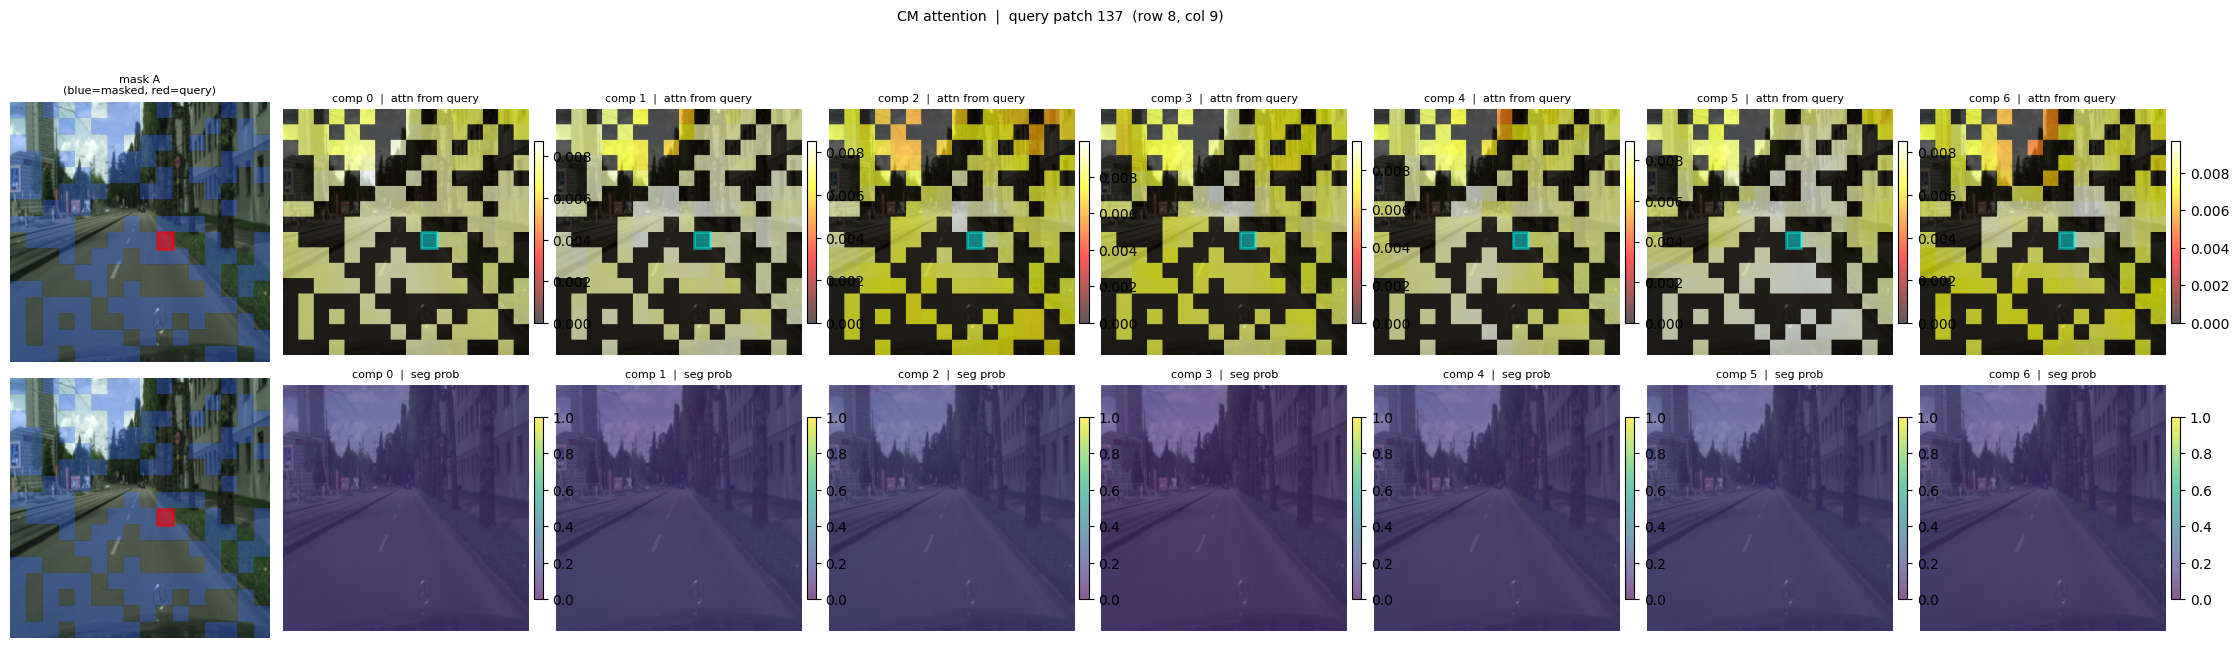

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def visualize_cm_attention(
    img,           # (C, H, W)  tanh-normalised, single image
    mask_a,        # (N,) or (1, N)  1 = masked in pass A
    attn_weights,  # list of N_comp tensors, each (1, N, N)  head-averaged
    seg_probs,     # (1, N_comp, H, W) or (N_comp, H, W)  after softmax
    query_patch,   # int — patch index to inspect (must be masked in pass A)
    patch_size=16,
):
    """
    For a single query patch (masked in pass A) show, for every component:
      - Top row : attention heatmap from the query to visible patches
      - Bottom row: segmentation probability map for that component

    The attention is re-normalised to visible keys only (masked positions
    hold mask-token embeddings and carry no content signal), matching what
    CrossMaskConsistencyLoss does internally.

    Usage
    -----
    with torch.no_grad():
        preds, mask_a, attn_weights = rec_model(img.unsqueeze(0), return_attn=True)
        seg_logits = seg_model(img.unsqueeze(0))
        seg_probs  = torch.softmax(seg_logits, dim=1)

    visualize_cm_attention(img, mask_a[0], attn_weights, seg_probs, query_patch=42)
    """
    C, H, W  = img.shape
    mask_a   = mask_a.reshape(-1).float().cpu()   # (N,)
    N        = mask_a.shape[0]
    h        = H // patch_size
    N_comp   = len(attn_weights)

    assert mask_a[query_patch] == 1, (
        f"query_patch {query_patch} is visible in pass A (mask_a == 0). "
        f"Pick a patch where mask_a == 1."
    )

    visible_flag = (1.0 - mask_a)                 # (N,)  1 = visible
    qi, qj       = query_patch // h, query_patch % h
    img_disp     = img.mul(0.5).add(0.5).clamp(0, 1).permute(1, 2, 0).cpu().numpy()

    fig, axes = plt.subplots(
        2, N_comp + 1,
        figsize=(3.5 * (N_comp + 1), 7),
        gridspec_kw={"hspace": 0.05, "wspace": 0.05},
    )

    # ── Column 0: original image + mask overview ──────────────────────────
    for row in range(2):
        ax = axes[row, 0]
        ax.imshow(img_disp)

        # blue tint on masked patches
        overlay = np.zeros((H, W, 4), dtype=np.float32)
        mask_grid = mask_a.reshape(h, h).numpy()
        for pi in range(h):
            for pj in range(h):
                if mask_grid[pi, pj] == 1:
                    r0, r1 = pi * patch_size, (pi + 1) * patch_size
                    c0, c1 = pj * patch_size, (pj + 1) * patch_size
                    overlay[r0:r1, c0:c1] = [0.2, 0.4, 1.0, 0.35]
        ax.imshow(overlay)

        # red highlight on query patch
        rect = mpatches.Rectangle(
            (qj * patch_size, qi * patch_size), patch_size, patch_size,
            linewidth=2, edgecolor="red", facecolor="red", alpha=0.55,
        )
        ax.add_patch(rect)
        ax.axis("off")

    axes[0, 0].set_title("mask A\n(blue=masked, red=query)", fontsize=8)
    axes[1, 0].set_title("", fontsize=8)

    # ── Columns 1…N_comp: per-component attention + seg ──────────────────
    for n, attn in enumerate(attn_weights):
        attn_n = attn[0].cpu()                    # (N, N)  remove batch dim

        # re-normalise to visible keys only
        attn_vis = attn_n * visible_flag.unsqueeze(0)        # (N, N)
        attn_vis = attn_vis / (attn_vis.sum(dim=-1, keepdim=True) + 1e-8)

        # attention vector FROM the query patch  →  (N,)
        query_attn = attn_vis[query_patch].numpy()           # only visible slots non-zero

        # upsample to pixel space via nearest-neighbour (same as mask upsampling)
        heatmap = query_attn.reshape(h, h)
        heatmap_px = np.kron(heatmap, np.ones((patch_size, patch_size)))  # (H, W)

        # ── top: attention heatmap ────────────────────────────────────────
        ax_top = axes[0, n + 1]
        ax_top.imshow(img_disp)
        im_attn = ax_top.imshow(heatmap_px, alpha=0.65, cmap="hot", vmin=0)
        # re-draw query highlight
        rect = mpatches.Rectangle(
            (qj * patch_size, qi * patch_size), patch_size, patch_size,
            linewidth=2, edgecolor="cyan", facecolor="cyan", alpha=0.45,
        )
        ax_top.add_patch(rect)
        ax_top.set_title(f"comp {n}  |  attn from query", fontsize=8)
        ax_top.axis("off")
        plt.colorbar(im_attn, ax=ax_top, fraction=0.035, pad=0.02)

        # ── bottom: segmentation probability ─────────────────────────────
        sp = seg_probs
        if sp.dim() == 4:
            sp = sp[0]                             # (N_comp, H, W)
        seg_n = sp[n].cpu().numpy()               # (H, W)

        ax_bot = axes[1, n + 1]
        ax_bot.imshow(img_disp)
        im_seg = ax_bot.imshow(seg_n, alpha=0.65, cmap="viridis", vmin=0, vmax=1)
        ax_bot.set_title(f"comp {n}  |  seg prob", fontsize=8)
        ax_bot.axis("off")
        plt.colorbar(im_seg, ax=ax_bot, fraction=0.035, pad=0.02)

    fig.suptitle(
        f"CM attention  |  query patch {query_patch}  "
        f"(row {qi}, col {qj})",
        fontsize=10, y=1.01,
    )
    plt.tight_layout()
    return fig


# ── Example usage (paste into a notebook cell) ────────────────────────────────
#
# from visualize_cm_attention import visualize_cm_attention
#
data, _ = next(iter(train_loader))
img = data[0].to(device)                # pick first image in batch

with torch.no_grad():
    preds, mask_a, attn_weights = rec_model(img.unsqueeze(0), return_attn=True)
    seg_logits = seg_model(img.unsqueeze(0))
    seg_probs  = torch.softmax(seg_logits, dim=1)

# pick any patch index where mask_a[0, idx] == 1
masked_indices = mask_a[0].nonzero(as_tuple=True)[0].tolist()
query = masked_indices[len(masked_indices) // 2]   # middle masked patch

fig = visualize_cm_attention(img, mask_a[0], attn_weights, seg_probs, query_patch=query)
plt.savefig("cm_attention.png")